# Project Overview


This project focuses on analyzing and predicting car prices using a range of machine learning algorithms and statistical methods. By utilizing a dataset that includes key features such as manufacturer, model, mileage, engine size, and other relevant attributes, the objective is to uncover patterns and insights that drive car pricing. The end goal is to develop a predictive model capable of delivering accurate price estimates, while also highlighting the most influential factors affecting vehicle valuations.



# Goals


1.Exploratory Data Analysis (EDA):

- Visualize the relationships between car features using pair plots, histograms, box plots, and correlation matrices.

- Identify trends, patterns, and outliers in the dataset that could influence car pricing.

2.Feature Engineering and Selection:

- Conduct feature importance analysis using tree-based methods like Random Forest.

- Examine correlations and remove redundant features to identify the most relevant predictors for car price estimation.

3.Data Preprocessing:

- Normalize and scale the dataset to ensure compatibility with machine learning algorithms.
  
- Handle missing values, outliers, and duplicates to maintain data quality and consistency.
  
4.Model Development and Evaluation:

- Implement and compare the performance of various machine learning models, including:

- Linear Regression

- Polynomial Regression

- Random Forest

- Support Vector Machines (SVM)

- Decision Trees

- K-Nearest Neighbors (KNN)

Optimize hyperparameters for each model using techniques like grid search and randomized search cross-validation.

Evaluate models on metrics such as R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE).

5.Insights and Interpretability:

- Analyze feature importances to determine the factors that most significantly impact car prices.

- Use visualization and feature reduction techniques to enhance interpretability and highlight actionable insights.

6.Final Model Selection and Deployment:

- Select the best-performing model based on evaluation metrics and robustness.

- Prepare the model for deployment in real-world applications to provide accurate car price predictions.

# Workflow

- Import Required Libraries  
- Load and Clean the Data  
- Data Preprocessing  
- Exploratory Data Analysis (EDA)  
- Model Training and Optimization  
- Feature Importance Analysis  
- Results and Reporting

# Import Libraries

In [97]:
!pip install scikit-learn

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Data Initialization

The data initialization phase is a crucial starting point in any machine learning pipeline. This step involves loading, inspecting, and preparing the dataset for further analysis. In this project, we initialize the dataset with the following steps:

In [99]:
file_path = '/kaggle/input/car-data/car_price_prediction.csv'
df = pd.read_csv(file_path)
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [100]:
df.set_index('ID', inplace=True)

In [101]:
df

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
ID,,,,,,,,,,,,,,,,,
45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4


In [102]:
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Column : {col}")
    print(f"Unique Values ({len(unique_vals)}) : {unique_vals}")
    print("-" * 50)

Column : Price
Unique Values (2315) : [13328 16621  8467 ... 56814 63886 22075]
--------------------------------------------------
Column : Levy
Unique Values (559) : ['1399' '1018' '-' '862' '446' '891' '761' '751' '394' '1053' '1055'
 '1079' '810' '2386' '1850' '531' '586' '1249' '2455' '583' '1537' '1288'
 '915' '1750' '707' '1077' '1486' '1091' '650' '382' '1436' '1194' '503'
 '1017' '1104' '639' '629' '919' '781' '530' '640' '765' '777' '779' '934'
 '769' '645' '1185' '1324' '830' '1187' '1111' '760' '642' '1604' '1095'
 '966' '473' '1138' '1811' '988' '917' '1156' '687' '11714' '836' '1347'
 '2866' '1646' '259' '609' '697' '585' '475' '690' '308' '1823' '1361'
 '1273' '924' '584' '2078' '831' '1172' '893' '1872' '1885' '1266' '447'
 '2148' '1730' '730' '289' '502' '333' '1325' '247' '879' '1342' '1327'
 '1598' '1514' '1058' '738' '1935' '481' '1522' '1282' '456' '880' '900'
 '798' '1277' '442' '1051' '790' '1292' '1047' '528' '1211' '1493' '1793'
 '574' '930' '1998' '271' '706' '

In [103]:
df.drop('Levy', axis=1, inplace=True)

In [104]:
df.describe()

,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,1.855593e+04,2010.912824,4.582991,6.582627
std,1.905813e+05,5.668673,1.199933,4.320168
min,1.000000e+00,1939.000000,1.000000,0.000000
25%,5.331000e+03,2009.000000,4.000000,4.000000
50%,1.317200e+04,2012.000000,4.000000,6.000000
75%,2.207500e+04,2015.000000,4.000000,12.000000
max,2.630750e+07,2020.000000,16.000000,16.000000


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19237 entries, 45654403 to 45813273
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             19237 non-null  int64  
 1   Manufacturer      19237 non-null  object 
 2   Model             19237 non-null  object 
 3   Prod. year        19237 non-null  int64  
 4   Category          19237 non-null  object 
 5   Leather interior  19237 non-null  object 
 6   Fuel type         19237 non-null  object 
 7   Engine volume     19237 non-null  object 
 8   Mileage           19237 non-null  object 
 9   Cylinders         19237 non-null  float64
 10  Gear box type     19237 non-null  object 
 11  Drive wheels      19237 non-null  object 
 12  Doors             19237 non-null  object 
 13  Wheel             19237 non-null  object 
 14  Color             19237 non-null  object 
 15  Airbags           19237 non-null  int64  
dtypes: float64(1), int64(3), object(12)

# Handling Non-Numeric Features

The LabelEncoder class from the sklearn.preprocessing module is used to convert categorical data into numerical form. It is particularly helpful when machine learning algorithms require input features to be numerical, as most models cannot process raw categorical data directly.

In [106]:
from sklearn.preprocessing import LabelEncoder

In [107]:
encoder = LabelEncoder()

In [108]:
df['Manufacturer'] = encoder.fit_transform(df['Manufacturer'])
df['Model'] = encoder.fit_transform(df['Model'])
df['Category'] = encoder.fit_transform(df['Category'])
df['Leather interior'] = encoder.fit_transform(df['Leather interior'])
df['Fuel type'] = encoder.fit_transform(df['Fuel type'])
df['Gear box type'] = encoder.fit_transform(df['Gear box type'])
df['Drive wheels'] = encoder.fit_transform(df['Drive wheels'])
df['Doors'] = encoder.fit_transform(df['Doors'])
df['Wheel'] = encoder.fit_transform(df['Wheel'])
df['Color'] = encoder.fit_transform(df['Color'])
df['Engine volume'] = encoder.fit_transform(df['Engine volume'])

In [109]:
df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)

In [110]:
df

,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
ID,,,,,,,,,,,,,,,,
45654403,13328,32,1242,2010,4,1,2,63,186005,6.0,0,0,1,0,12,12
44731507,16621,8,658,2011,4,0,5,56,192000,6.0,2,0,1,0,1,8
45774419,8467,21,684,2006,3,0,5,22,200000,4.0,3,1,1,1,1,2
45769185,3607,16,661,2011,4,1,2,46,168966,4.0,0,0,1,0,14,0
45809263,11726,21,684,2014,3,1,5,22,91901,4.0,0,1,1,0,12,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45798355,8467,36,385,1999,1,1,0,37,300000,4.0,1,2,0,0,12,5
45778856,15681,23,1334,2011,9,1,5,44,161600,4.0,2,1,1,0,11,8
45804997,26108,23,1442,2010,4,1,1,36,116365,4.0,0,1,1,0,7,4


In [111]:
df.describe()

,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
count,1.923700e+04,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,1.923700e+04,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000
mean,1.855593e+04,33.080678,862.592348,2010.912824,6.265582,0.725373,3.432396,41.462234,1.532236e+06,4.582991,0.536310,0.908874,0.966263,0.077143,7.776005,6.582627
std,1.905813e+05,17.766465,410.812287,5.668673,2.790570,0.446338,1.807388,15.315334,4.840387e+07,1.199933,0.896607,0.567875,0.214264,0.266825,5.363884,4.320168
min,1.000000e+00,0.000000,0.000000,1939.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.331000e+03,21.000000,537.000000,2009.000000,4.000000,0.000000,2.000000,32.000000,7.013900e+04,4.000000,0.000000,1.000000,1.000000,0.000000,1.000000,4.000000
50%,1.317200e+04,32.000000,834.000000,2012.000000,7.000000,1.000000,5.000000,36.000000,1.260000e+05,4.000000,0.000000,1.000000,1.000000,0.000000,7.000000,6.000000
75%,2.207500e+04,54.000000,1226.000000,2015.000000,9.000000,1.000000,5.000000,46.000000,1.888880e+05,4.000000,1.000000,1.000000,1.000000,0.000000,12.000000,12.000000
max,2.630750e+07,64.000000,1589.000000,2020.000000,10.000000,1.000000,6.000000,106.000000,2.147484e+09,16.000000,3.000000,2.000000,2.000000,1.000000,15.000000,16.000000


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19237 entries, 45654403 to 45813273
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             19237 non-null  int64  
 1   Manufacturer      19237 non-null  int64  
 2   Model             19237 non-null  int64  
 3   Prod. year        19237 non-null  int64  
 4   Category          19237 non-null  int64  
 5   Leather interior  19237 non-null  int64  
 6   Fuel type         19237 non-null  int64  
 7   Engine volume     19237 non-null  int64  
 8   Mileage           19237 non-null  int64  
 9   Cylinders         19237 non-null  float64
 10  Gear box type     19237 non-null  int64  
 11  Drive wheels      19237 non-null  int64  
 12  Doors             19237 non-null  int64  
 13  Wheel             19237 non-null  int64  
 14  Color             19237 non-null  int64  
 15  Airbags           19237 non-null  int64  
dtypes: float64(1), int64(15)
memory usa

# Visualization and Analysis

- Pair Plot
- Histogram
- Box Plot
- Correlation Matrix

## Pair Plot

### Overview :
- Diagonal: Distribution of individual features using histograms or kernel density estimates (KDE).
- Off-diagonal: Pairwise scatterplots between features to analyze their relationships.

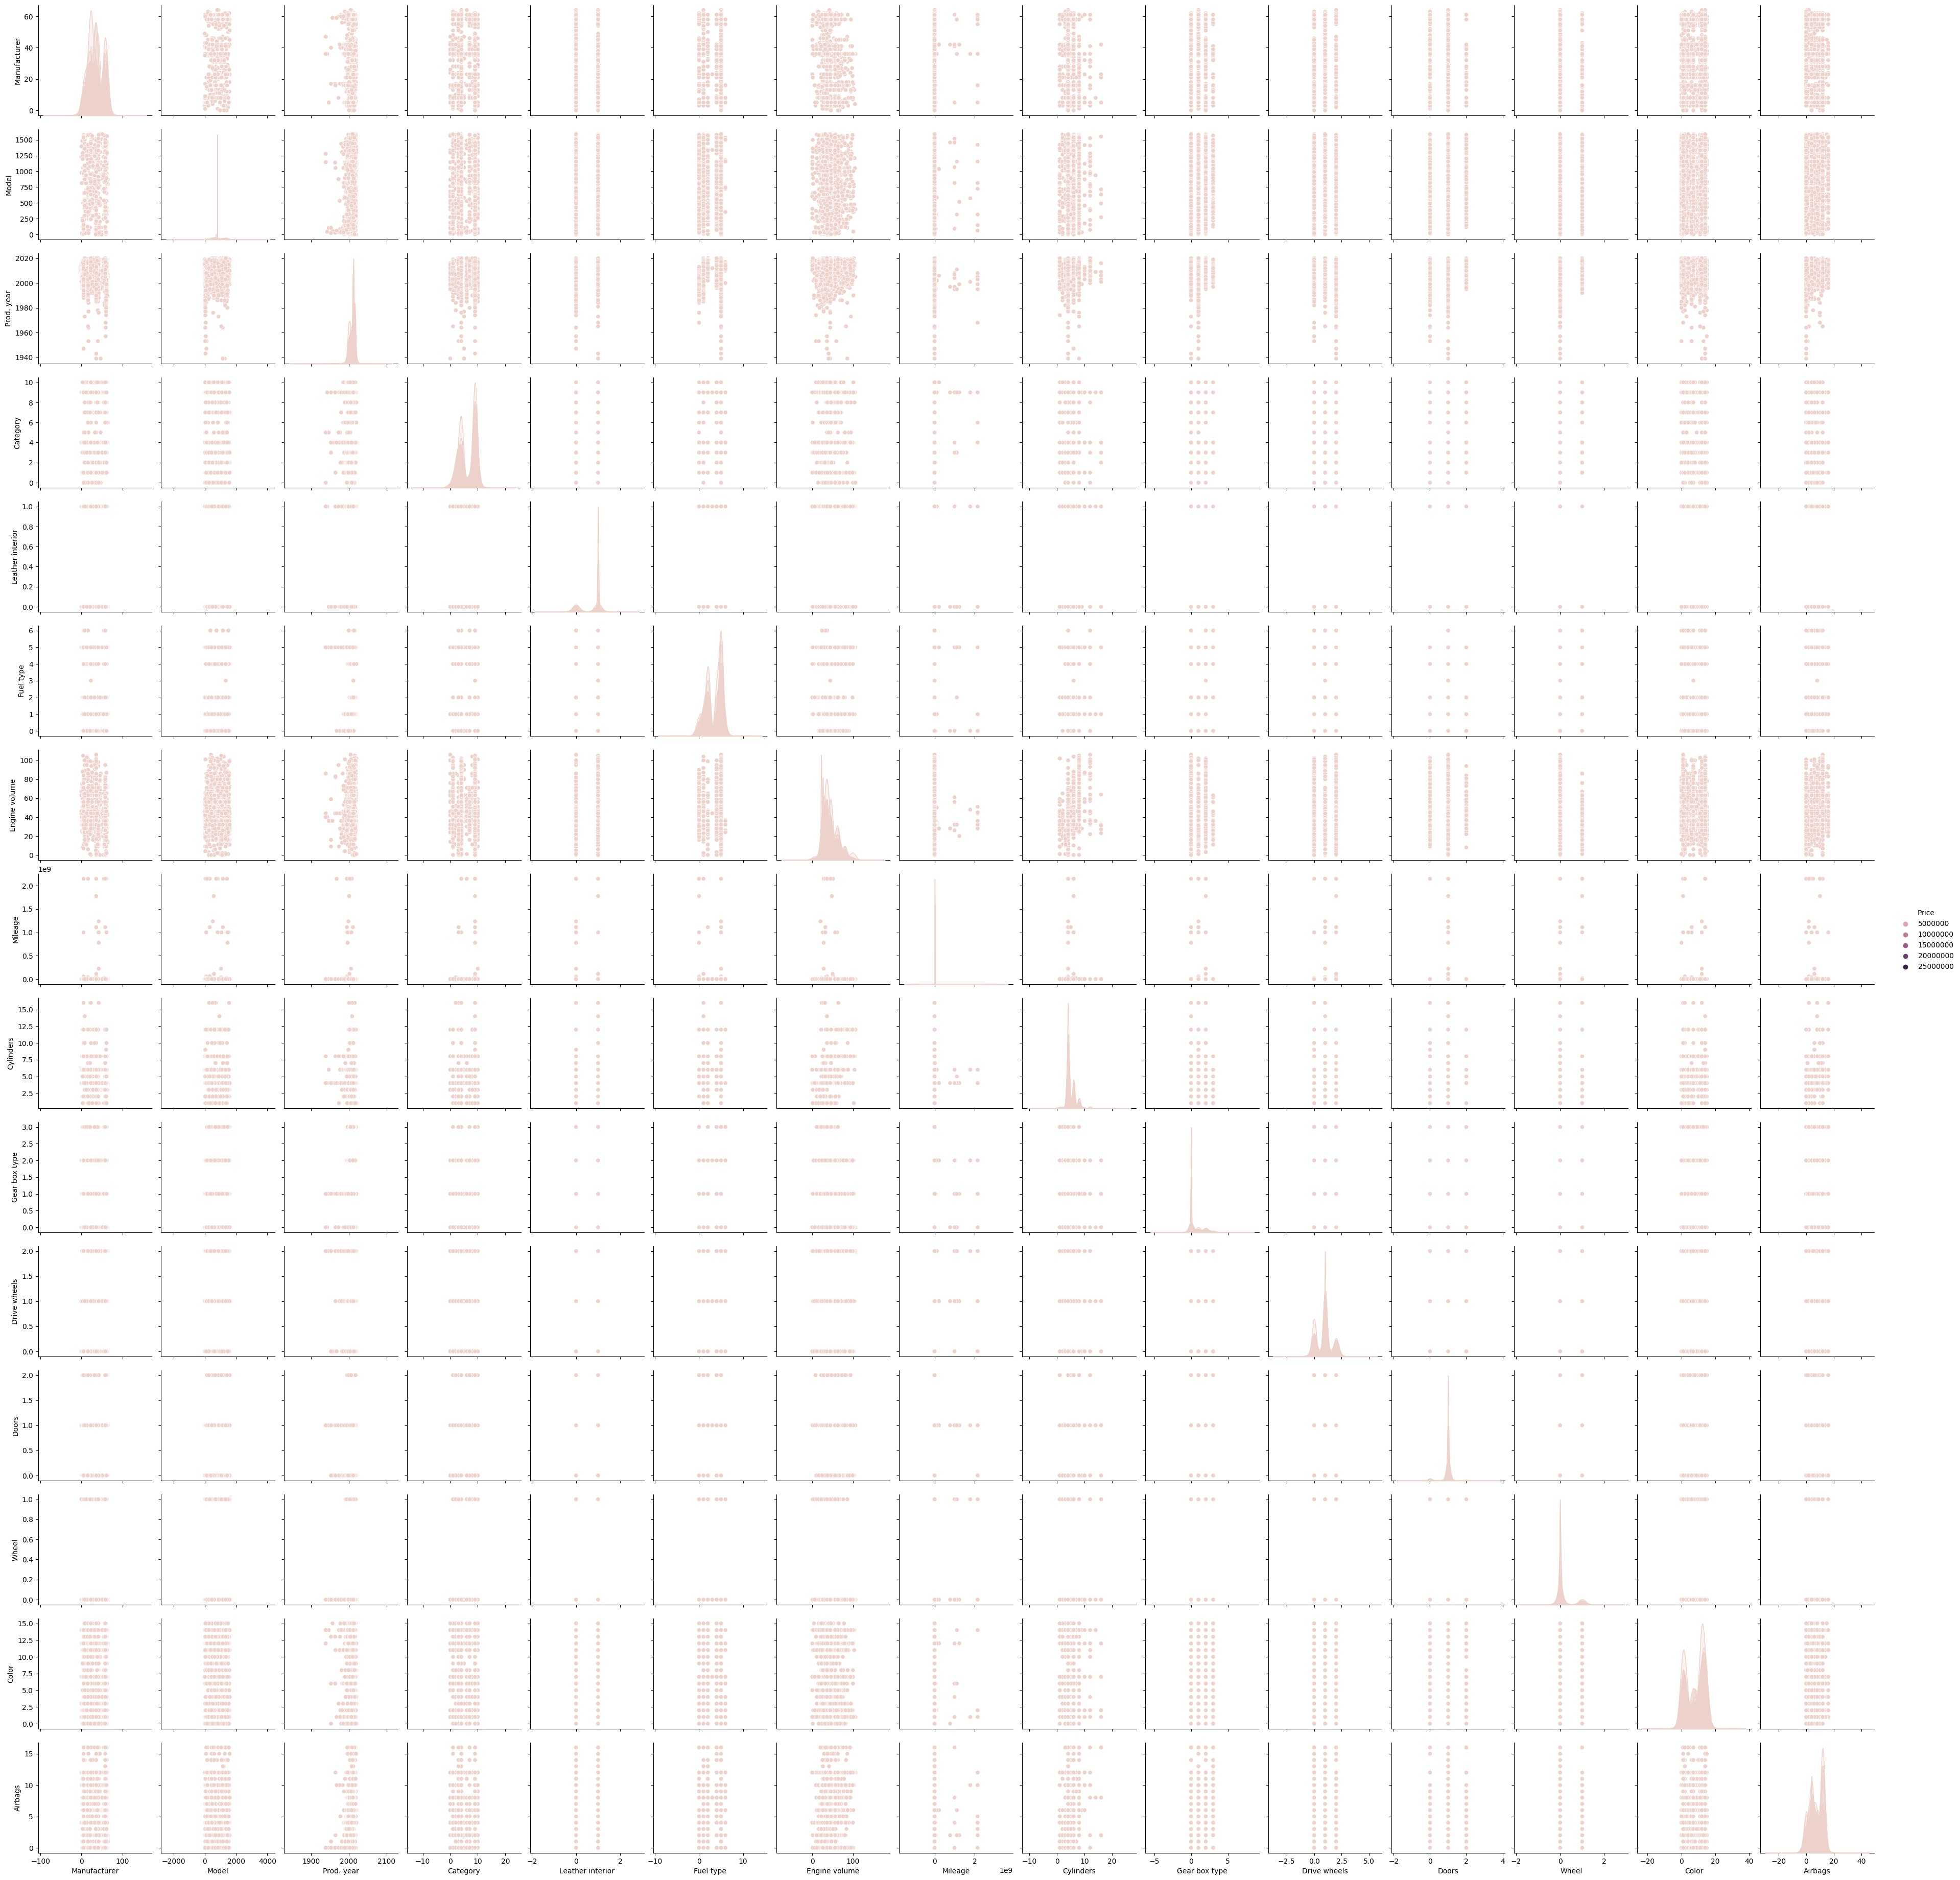

In [113]:
sns.pairplot(df, hue='Price')
plt.show()

### Observations :
- Feature Distributions
  
    - Price: Right-skewed; most cars are low-priced, few high-priced outliers.
    - Mileage: Clustered at intervals (e.g., 10k, 20k km), indicating grouping.
    - Engine Volume: Peaks at common sizes (2.0, 3.0 liters).
    - Cylinders: Discrete values; most cars have 4, 6, or 8 cylinders.

- Pairwise Relationships

    - Price vs. Mileage: Slight negative correlation — higher mileage, lower price.
    - Price vs. Engine Volume: Slight positive correlation — bigger engines, higher price.
    - Engine Volume vs. Cylinders: Strong positive correlation.
    - Category vs. Price: Premium categories linked to higher prices.
    - Leather Interior vs. Price: Leather interiors often found in high-priced cars.

### Insights :

- Feature Engineering: Focus on impactful features like Mileage, Engine Volume, Cylinders, and Category. Explore feature interactions (e.g., Drive Wheels × Engine Volume).
- Outlier Handling: Review outliers in Price and Engine Volume to avoid model distortion.
- Transformations: Apply log/power transforms to skewed variables (e.g., Price, Mileage) for better model performance.
- Correlation Analysis: Use pairplots and heatmaps to visualize and quantify relationships.


## Histogram 

### Overview :

A histplot (histogram plot) is a visualization that shows the distribution of a single variable by dividing data into bins and displaying the count of values in each bin as bars. It’s useful for understanding the spread, skewness, modality (e.g., unimodal, bimodal), and presence of outliers in data. In machine learning and data analysis, histograms help identify patterns in the data, which can inform preprocessing steps like normalization, scaling, or transformation.

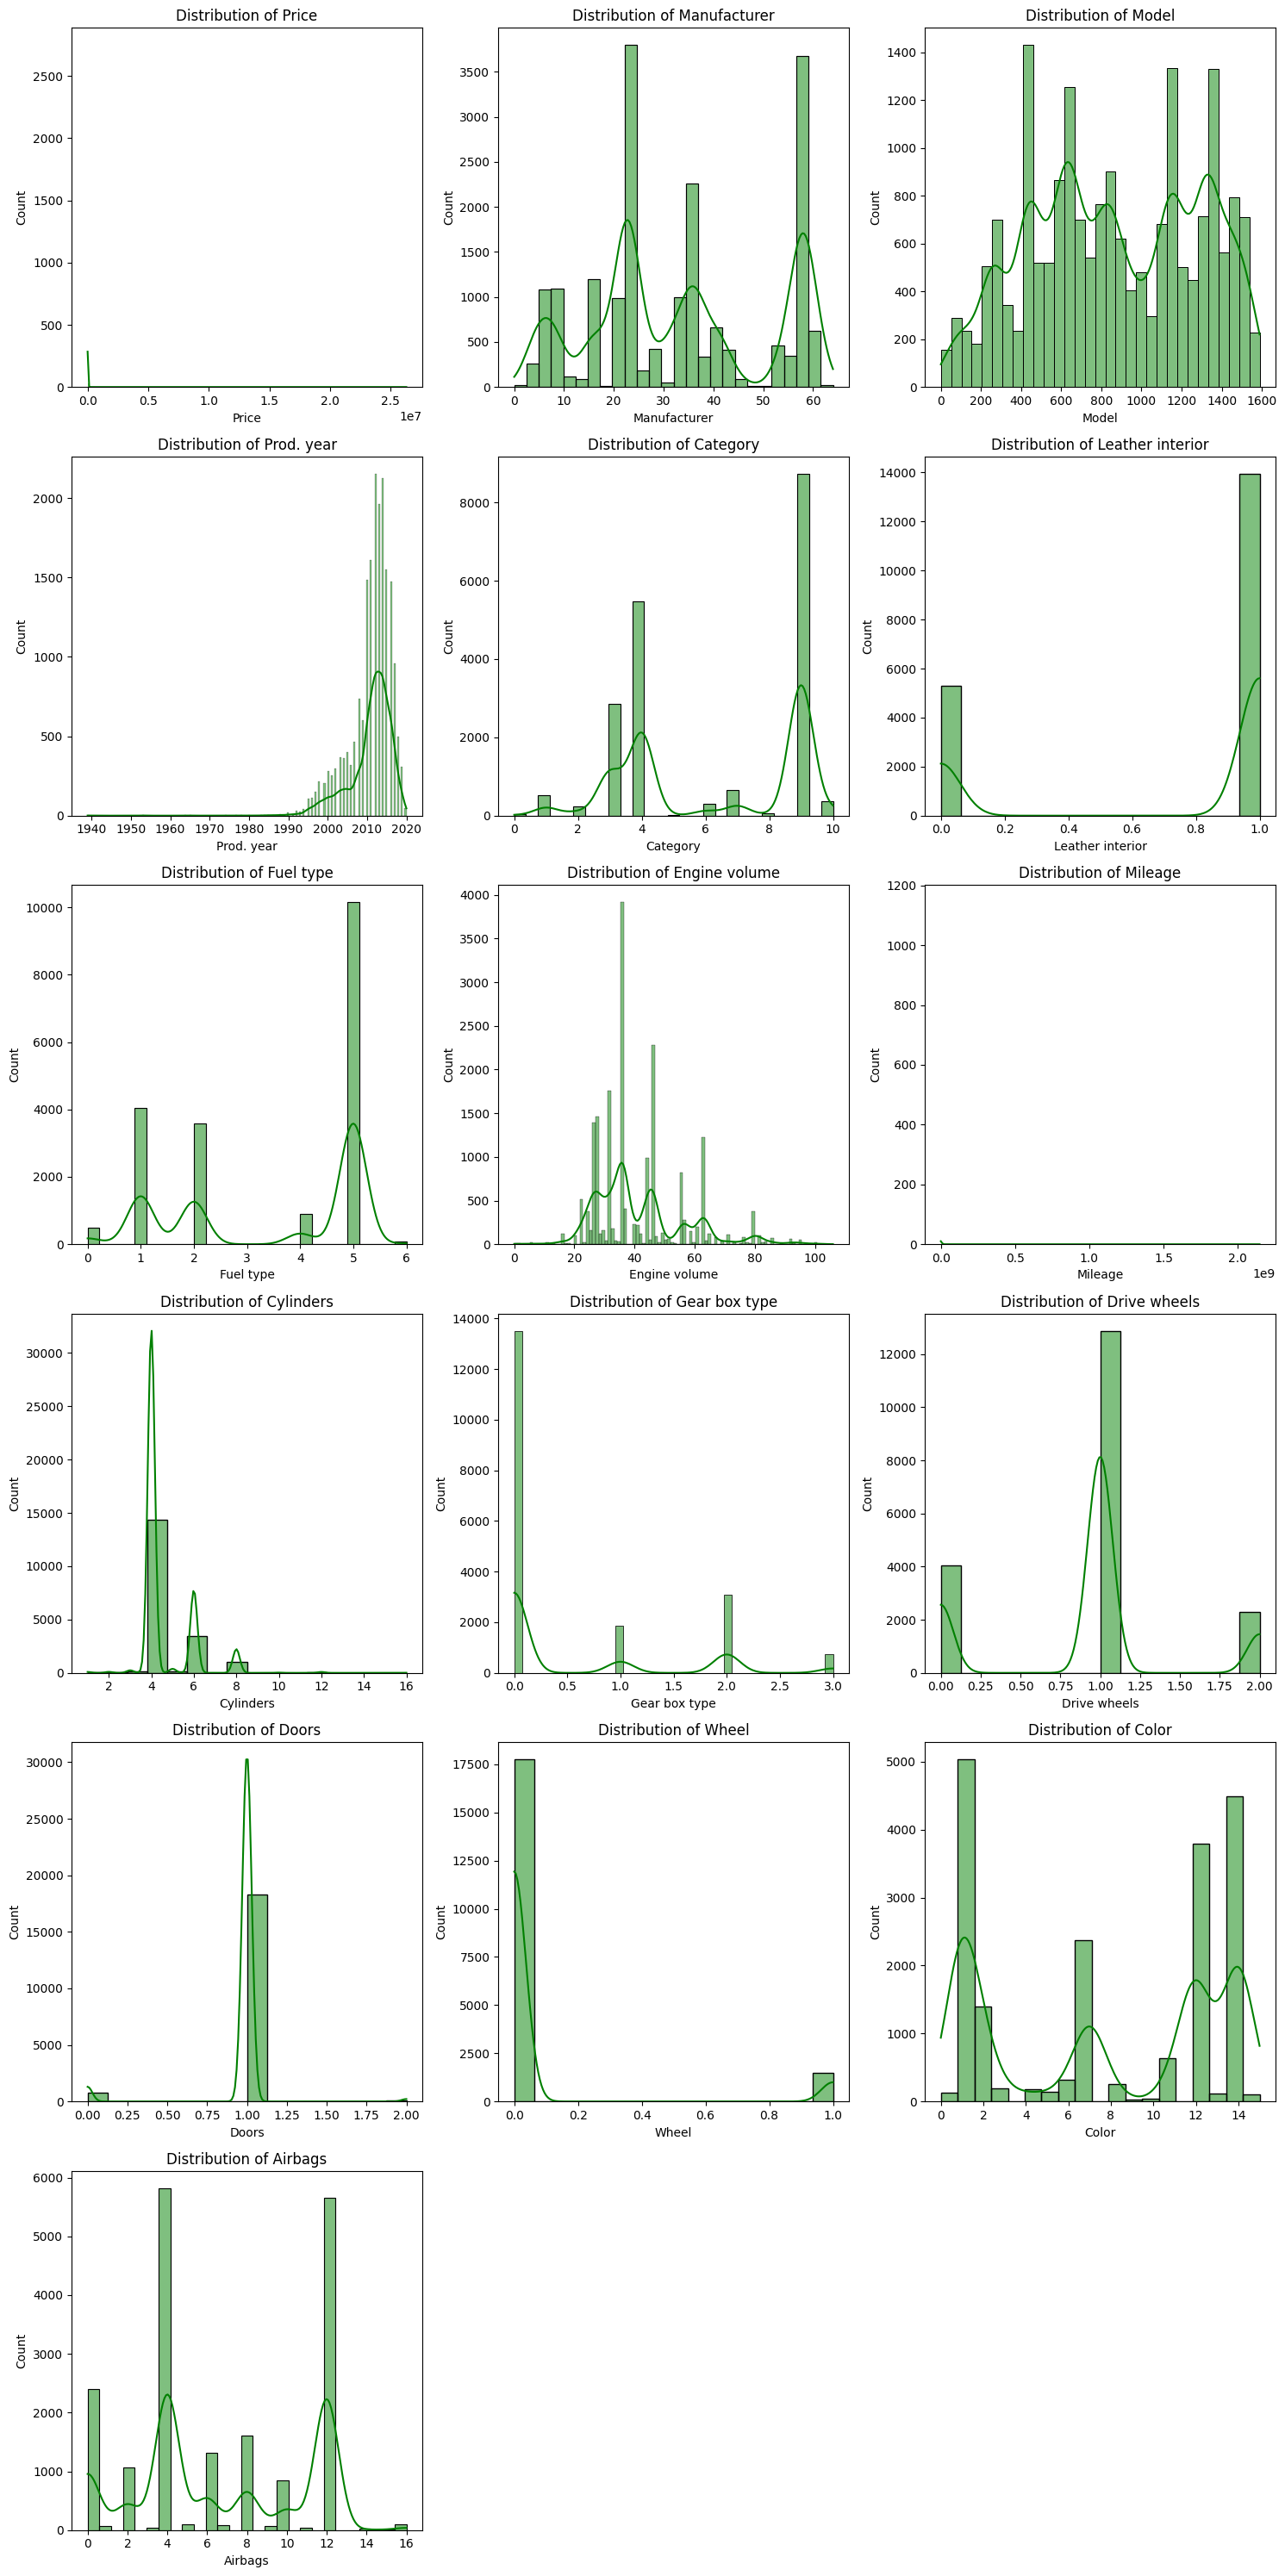

In [114]:
numeric_columns = df.select_dtypes(include=['number']).columns

n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(df[column], kde=True, ax=axes[i], color = 'green')
    axes[i].set_title(f'Distribution of {column}')

if len(numeric_columns) < len(axes):
    for j in range(len(numeric_columns), len(axes)):
        axes[j].set_visible(False)


plt.tight_layout()
plt.savefig('numeric_columns_distribution.png')
plt.show()

### Observations :

- Price: Right-skewed; most cars are low-priced, a few high-priced outliers exist.
- Manufacturer & Model: Few brands/models dominate, indicating dataset imbalance and potential price influence.
- Production Year: Mostly recent cars, likely priced higher.
= Category & Fuel Type: Common types dominate; rare ones are limited.
- Engine Volume & Mileage: Popular engine sizes; low mileage common—both affecting price.
- Gearbox & Drive Wheels: Manual and front-wheel drives dominate.
- Doors & Wheel Position: 4-door and left-hand drive cars are most common.
- Color & Airbags: Popular colors like black/white prevail; safety features vary by airbag count.

### Insights :

- Skewed distributions for several variables like price and mileage indicate that some features may have significant outliers or a non-uniform spread across values.
- Popularity and utility play a significant role in the distribution of categories like car type, fuel type, and doors, which could impact pricing trends.
- Modern cars dominate the dataset (especially in terms of production year), which may indicate that newer vehicles are the primary focus for pricing and prediction models.

## Box Plot

### Overview :

A box plot (or box-and-whisker plot) is a visualization used to display the distribution, spread, and skewness of data through quartiles. It highlights the median, interquartile range (IQR), and potential outliers for a variable.

- Median: The central line in the box represents the median (50th percentile) of the data.
- IQR (Interquartile Range): The box represents the middle 50% of the data, spanning from the first quartile (25th percentile) to the third quartile (75th percentile).
- Whiskers: The lines (whiskers) extending from the box show the range within 1.5 times the IQR.
- Outliers: Data points outside this range are plotted as individual points and considered potential outliers.

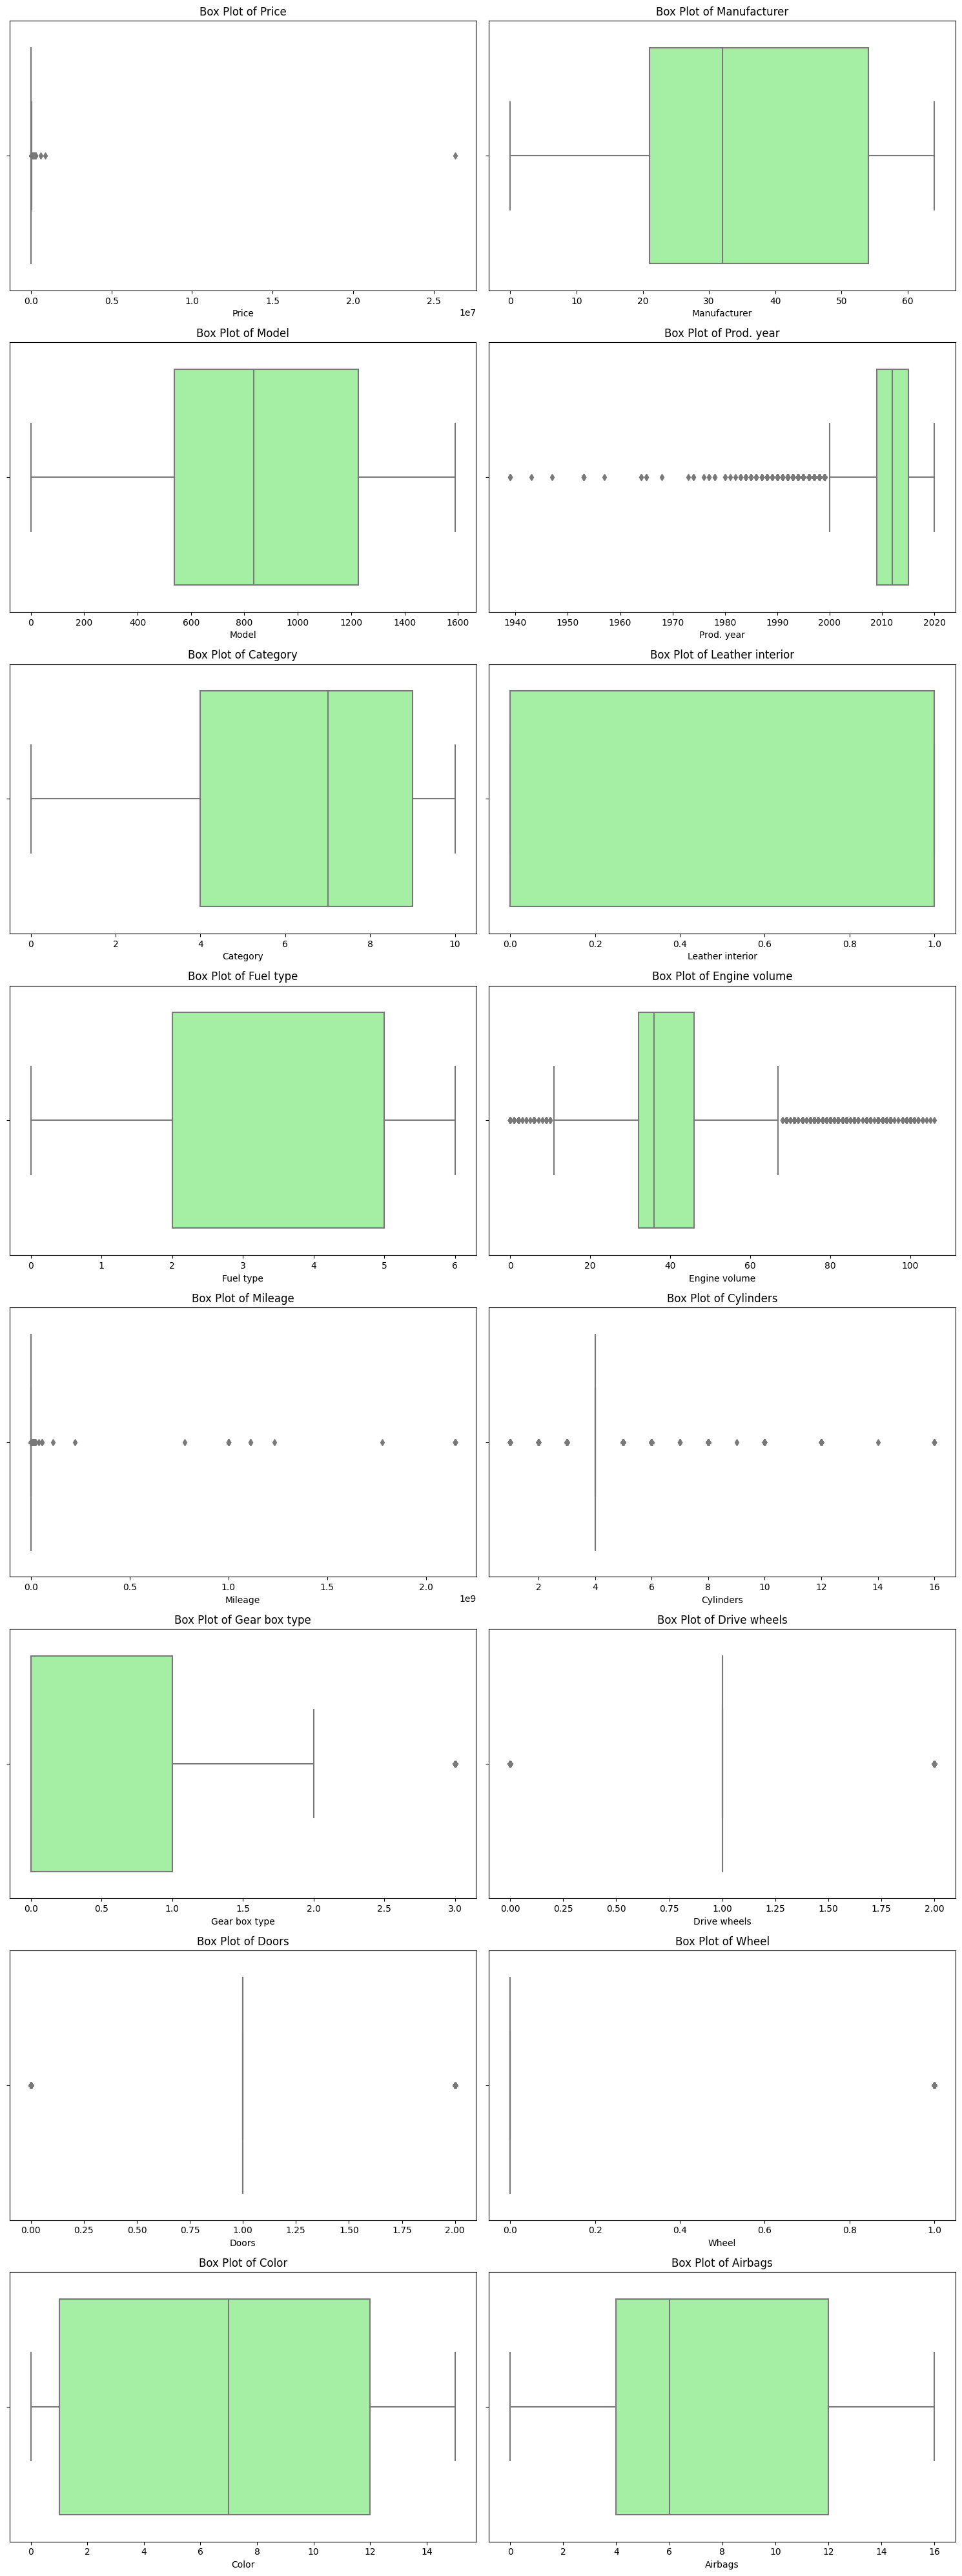

In [115]:
n_cols = 2
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(x=df[column], ax=axes[i], color = 'palegreen')
    axes[i].set_title(f'Box Plot of {column}')

if len(numeric_columns) < len(axes):
    for j in range(len(numeric_columns), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('numeric_columns_boxplots.png')
plt.show()

### Observations :

- Price: Right-skewed with a few luxury car outliers; most prices are tightly clustered.
- Manufacturer & Model: Tight distribution with outliers; some brands/models show extreme values.
- Production Year: Mostly recent models; older cars are outliers.
- Category & Fuel Type: Balanced spread with dominant types like SUVs, petrol/diesel.
- Engine Volume: Mostly moderate sizes; high-performance cars cause outliers.
- Mileage: Wide spread with some high-usage outliers.
- Gearbox & Drive Wheels: Manual/front-wheel drive dominate; others are outliers.
- Doors & Wheel: 4-door and left-hand drive cars are most common.
- Color: Fairly even distribution; popular colors slightly dominate.
- Airbags: Most cars fall in a common range; a few have extra safety features.
- Leather Interior: Binary distribution; majority fall into one category.

### Insights :

- Outliers: Features like Price, Mileage, and Engine Volume have outliers, likely representing luxury or rare cars.
- Concentration: Attributes such as Doors and Gear Box Type show tight distributions, indicating common traits (e.g., 4 doors, manual/automatic).
- Skewness: Features like Production Year and Mileage are skewed, which may require transformations for better model accuracy.

## Correlation Matrix

### Overview : 

A correlation heatmap is a graphical representation of the correlation matrix, where each cell in the matrix displays the correlation coefficient between two variables. Each value in this matrix represents the correlation coefficient between two features, indicating how strongly they are linearly related (with values ranging from -1 to 1). In this heatmap, colors represent the strength and direction of the correlation:

- Red shades indicate positive correlations (as one variable increases, the other tends to increase as well).
- Blue shades indicate negative correlations (as one variable increases, the other tends to decrease).
- Intensity of color shows the strength of the correlation: darker colors imply stronger correlations, whether positive or negative.
- Cells are masked to show only the upper triangle, given the matrix is symmetric around the diagonal.
- Correlation values range from -1 (strong negative correlation) to +1 (strong positive correlation).
- Values close to 0 indicate little to no linear relationship between variables.


In [116]:
corr = df.corr()

In [117]:
mask = np.triu(np.ones_like(corr, dtype=bool))

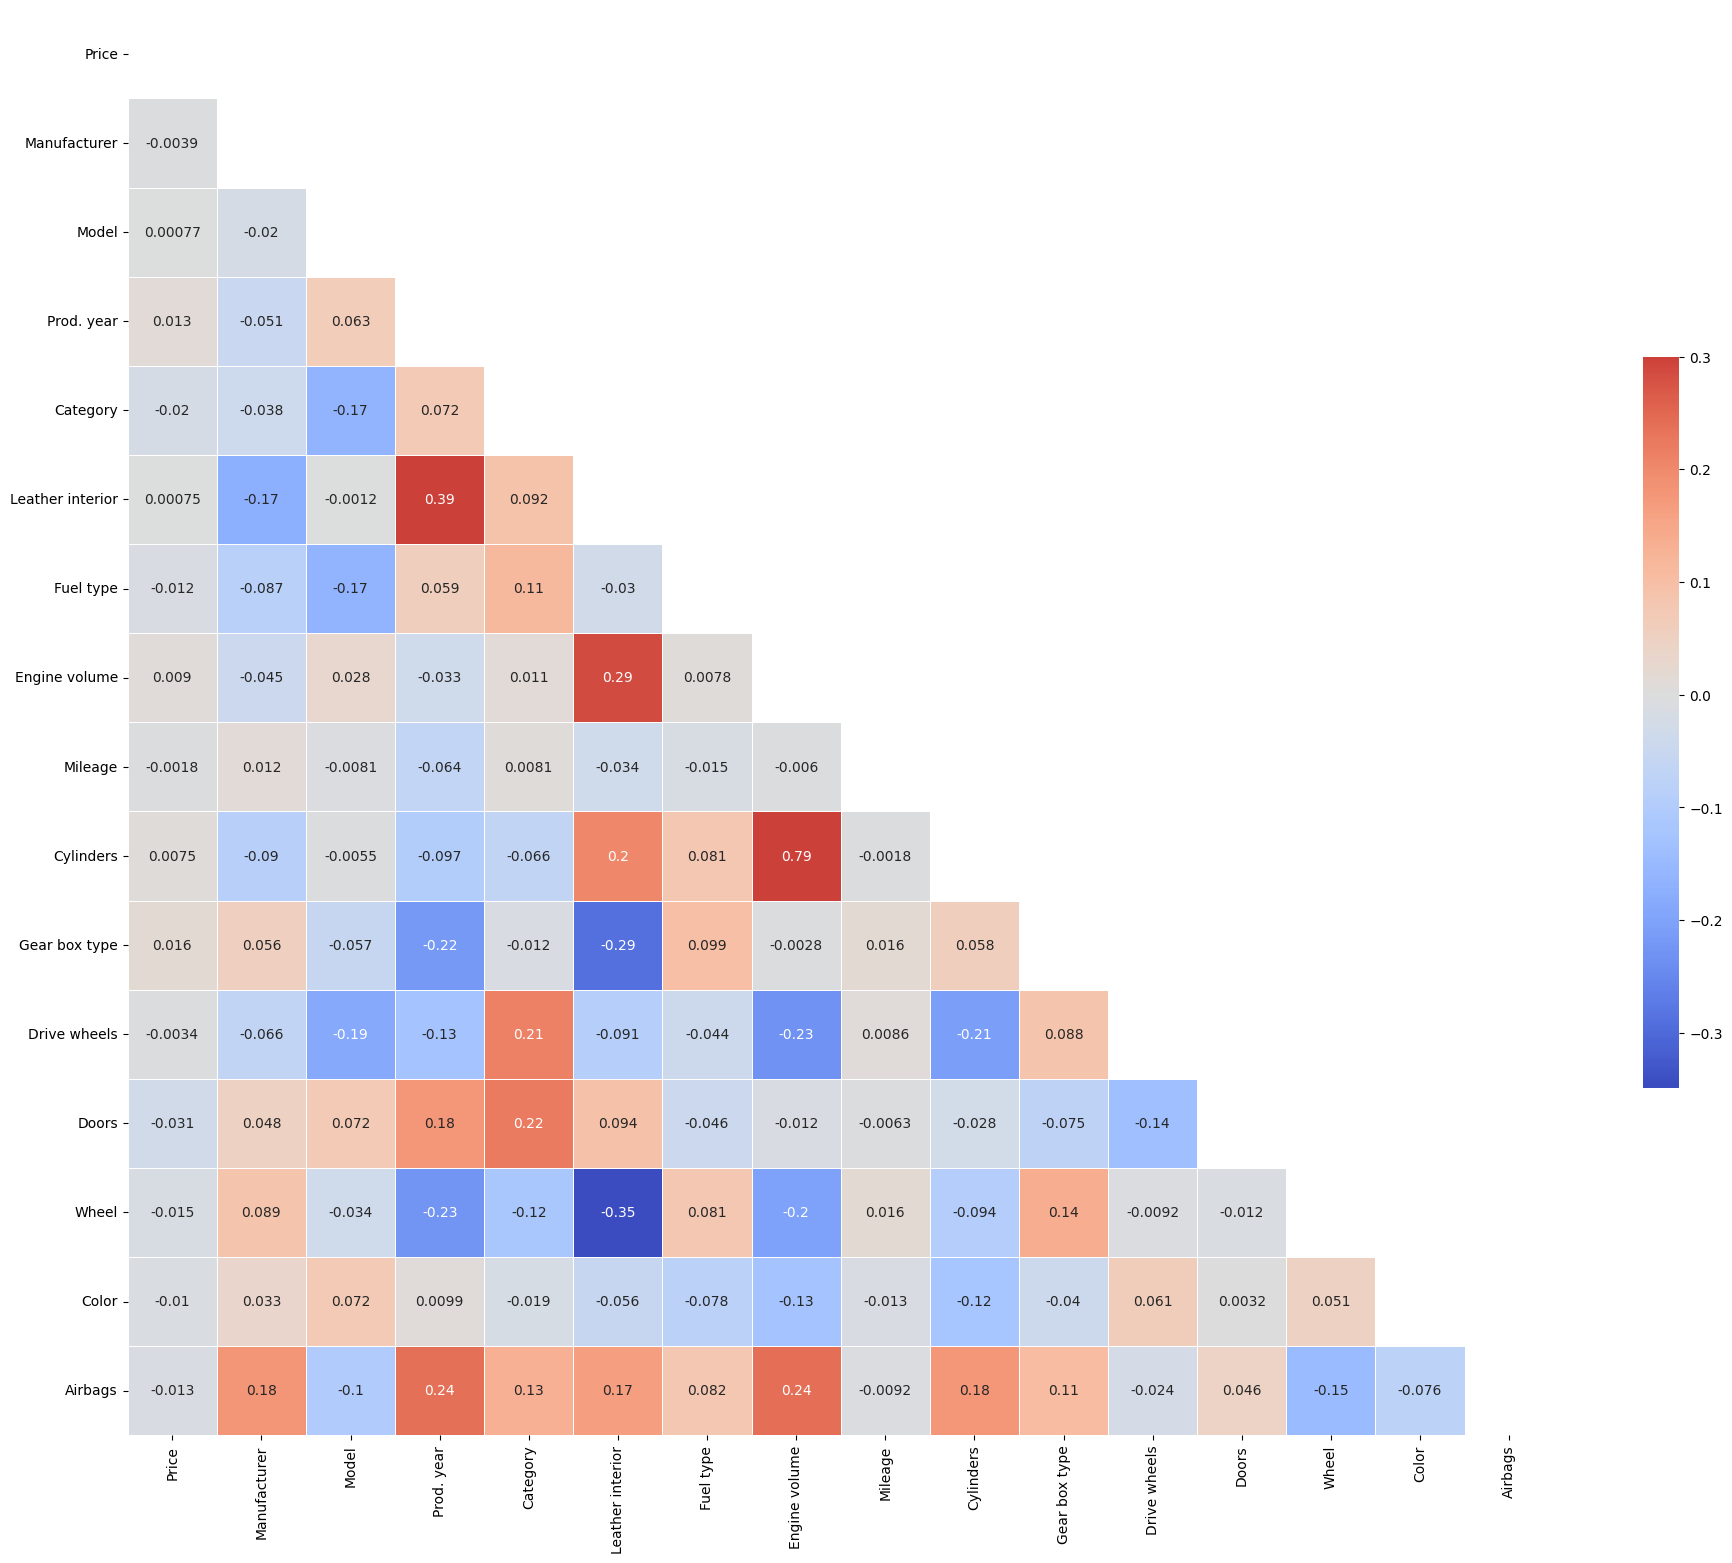

In [118]:
f, ax = plt.subplots(figsize=(23, 19))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5} , annot=True)

plt.show()

### Observations :

- Price has very weak correlations with most features; Manufacturer (-0.0039), Mileage (-0.0018), Model (-0.00077). Slight positive links exist with Production Year (0.013) and Cylinders (0.0075).

- Strong Feature Correlations:

    - Engine Volume & Cylinders (0.79): Larger engines usually have more cylinders.
    - Leather Interior & Category (0.39): Leather is more common in premium categories.
    - Wheel & Category (0.35): Wheel type relates to car category.
    - Drive Wheels & Engine Volume (0.23): Moderate link between drivetrain type and engine size.


- Weak or Negligible Links: Features like Fuel Type, Doors, Airbags, Mileage, Manufacturer, and Model show little correlation with price or each other.

### Insights

- Key Features: Engine volume, Cylinders, and Category are important predictors; Manufacturer and Mileage may be less useful.
- Multicollinearity: Strong correlation between Engine volume and Cylinders may affect model interpretability.
- Feature Engineering: Consider interactions like Drive wheels & Engine volume or Category & Leather interior.
- Price Modeling: Weak correlations suggest exploring non-linear relationships or feature transformations.

# Feature-target separation

x becomes a DataFrame containing all columns except Price, which will serve as the input features for machine learning models. y represents the target variable (dependent variable) that we aim to predict.

In [119]:
x = df.drop(['Price'], axis=1)
y = df['Price']

# Make Train and Test

The data is split into four parts:

- x_train: The training set for the input features (80% of x).

- x_test: The testing set for the input features (20% of x).
 
- y_train: The training set for the target variable (80% of y).

- y_test: The testing set for the target variable (20% of y).

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Data Preprocessing

The StandardScaler is used to standardize the dataset by scaling features to have a mean of 0 and a standard deviation of 1. This ensures that all features are on the same scale, improving model performance and reducing bias.

In [122]:
from sklearn.preprocessing import StandardScaler

In [123]:
scaler = StandardScaler()

In [124]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Machine Learning Models 

## Linear Regression

LinearRegression is a supervised machine learning algorithm used for regression tasks. It models the relationship between a dependent variable (target) and one or more independent variables (features) by fitting a linear equation to the observed data.

In [125]:
from sklearn.linear_model import LinearRegression

In [126]:
lr = LinearRegression()

In [127]:
lr.fit(x_train_scaled, y_train)

LinearRegression()

In [128]:
y_pred_test_lr = lr.predict(x_test_scaled)

In [129]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [130]:
mse_test_lr = mean_squared_error(y_pred_test_lr, y_test)
mae_test_lr = mean_absolute_error(y_pred_test_lr, y_test)
r2_test_lr = r2_score(y_pred_test_lr, y_test)

In [131]:
print(f'mean squared error is: {mse_test_lr}')
print(f'mean absolute error is: {mae_test_lr}')
print(f'R Squared is {r2_test_lr}')

mean squared error is: 393655371.83913326
mean absolute error is: 12768.7535699644
R Squared is -2.1629784660980835


## Polynomial Regression

PolynomialFeatures is a preprocessing class used to generate polynomial and interaction features from the input data. It is particularly useful when the relationship between features and the target variable is not linear, as it allows the transformation of the features into higher-degree polynomials.

In [132]:
from sklearn.preprocessing import PolynomialFeatures

In [133]:
poly = PolynomialFeatures()
x_poly_train = poly.fit_transform(x_train_scaled)
x_poly_test = poly.fit_transform(x_test_scaled)

In [134]:
pr = LinearRegression()
pr.fit(x_poly_train, y_train)

LinearRegression()

In [135]:
y_pred_test_pr = pr.predict(x_poly_test)

In [136]:
mse_test_pr = mean_squared_error(y_pred_test_pr, y_test)
mae_test_pr = mean_absolute_error(y_pred_test_pr, y_test)
r2_test_pr = r2_score(y_pred_test_pr, y_test)

In [137]:
print('Scores of test data from dataframe and Polynominal regression')
print(f'mean squared error is: {mse_test_pr}')
print(f'mean absolute error is: {mae_test_pr}')
print(f'R Squared is {r2_test_pr}')

Scores of test data from dataframe and Polynominal regression
mean squared error is: 201192190139.72433
mean absolute error is: 22967.369542111974
R Squared is -0.0009536886478904716


## Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) is a linear regression model that uses L1 regularization to improve model performance by penalizing the absolute values of the coefficients. It is particularly useful for feature selection and reducing overfitting.

In [138]:
from sklearn.linear_model import Lasso

In [139]:
lasso = Lasso()

In [140]:
lasso.fit(x_train_scaled , y_train)

Lasso()

In [141]:
y_pred_test_lasso = lasso.predict(x_test_scaled)

In [142]:
mse_test_lasso = mean_squared_error(y_pred_test_lasso, y_test)
mae_test_lasso = mean_absolute_error(y_pred_test_lasso, y_test)
r2_test_lasso = r2_score(y_pred_test_lasso, y_test)

In [143]:
print('Scores of test data from dataframe and Lasso regression')
print(f'mean squared error is: {mse_test_lasso}')
print(f'mean absolute error is: {mae_test_lasso}')
print(f'R Squared is {r2_test_lasso}')

Scores of test data from dataframe and Lasso regression
mean squared error is: 393621620.9072683
mean absolute error is: 12767.850996595767
R Squared is -2.164660660604547


## Ridge Regression

Ridge is a linear regression model that incorporates L2 regularization to improve model performance by penalizing the square of the coefficients. It helps reduce overfitting and improves the generalizability of the model by shrinking large coefficients.

In [144]:
from sklearn.linear_model import Ridge

In [145]:
ridge = Ridge()

In [146]:
ridge.fit(x_train_scaled , y_train)

Ridge()

In [147]:
y_pred_test_ridge = ridge.predict(x_test_scaled)

In [148]:
mse_test_ridge = mean_squared_error(y_pred_test_ridge, y_test)
mae_test_ridge = mean_absolute_error(y_pred_test_ridge, y_test)
r2_test_ridge = r2_score(y_pred_test_ridge, y_test)

In [149]:
print('Scores of test data from dataframe and Ridge')
print(f'mean squared error is: {mse_test_ridge}')
print(f'mean absolute error is: {mae_test_ridge}')
print(f'R Squared is {r2_test_ridge}')

Scores of test data from dataframe and Ridge
mean squared error is: 393646442.18686247
mean absolute error is: 12768.57686336919
R Squared is -2.1634461540316043


## SVR

SVR (Support Vector Regressor) is a supervised machine learning algorithm used for regression tasks. It is based on the Support Vector Machine (SVM) algorithm and aims to find a hyperplane that best fits the data within a specified margin of tolerance.

In [150]:
from sklearn.svm import SVR

In [151]:
from sklearn.model_selection import RandomizedSearchCV

In [152]:
svr = SVR()

param_grid_svr = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Different kernel functions
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel coefficient
    'epsilon': [0.1, 0.2, 0.5, 1],  # Tolerance for loss in the epsilon-tube
    'degree': [2, 3, 4],  # Degree of the polynomial kernel function (only used for 'poly')
}

In [153]:
rand_svr = RandomizedSearchCV(estimator=svr, param_distributions=param_grid_svr, cv=3, scoring='neg_mean_squared_error', verbose=3, return_train_score=True)
rand_svr.fit(x_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END C=10, degree=2, epsilon=1, gamma=auto, kernel=sigmoid;, score=(train=-352927283.632, test=-135247693778.631) total time=   9.9s
[CV 2/3] END C=10, degree=2, epsilon=1, gamma=auto, kernel=sigmoid;, score=(train=-67800174850.373, test=-369533649.922) total time=  10.0s
[CV 3/3] END C=10, degree=2, epsilon=1, gamma=auto, kernel=sigmoid;, score=(train=-67806035589.375, test=-336953624.862) total time=  10.0s
[CV 1/3] END C=100, degree=4, epsilon=0.1, gamma=1, kernel=rbf;, score=(train=-342328662.287, test=-135222174316.281) total time=   7.1s
[CV 2/3] END C=100, degree=4, epsilon=0.1, gamma=1, kernel=rbf;, score=(train=-67781840141.700, test=-360872599.518) total time=   7.2s
[CV 3/3] END C=100, degree=4, epsilon=0.1, gamma=1, kernel=rbf;, score=(train=-67787020314.291, test=-329222327.113) total time=   7.2s
[CV 1/3] END C=0.1, degree=3, epsilon=0.2, gamma=auto, kernel=sigmoid;, score=(train=-377433332.952, test=-13

RandomizedSearchCV(cv=3, estimator=SVR(),
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'degree': [2, 3, 4],
                                        'epsilon': [0.1, 0.2, 0.5, 1],
                                        'gamma': ['scale', 'auto', 0.001, 0.01,
                                                  0.1, 1],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   return_train_score=True, scoring='neg_mean_squared_error',
                   verbose=3)

In [154]:
rand_svr.best_params_

{'kernel': 'linear', 'gamma': 'scale', 'epsilon': 0.2, 'degree': 3, 'C': 10}

In [155]:
best_svr = SVR(kernel= 'sigmoid', gamma= 'auto', epsilon= 1, C=100, degree= 4)

In [156]:
best_svr.fit(x_train_scaled, y_train)

SVR(C=100, degree=4, epsilon=1, gamma='auto', kernel='sigmoid')

In [157]:
y_pred_test_svr = best_svr.predict(x_test_scaled)

In [158]:
mse_test_svr = mean_squared_error(y_pred_test_svr, y_test)
mae_test_svr = mean_absolute_error(y_pred_test_svr, y_test)
r2_test_svr = r2_score(y_pred_test_svr, y_test)

In [159]:
print('Scores of test data from dataframe and SVR')
print(f'mean squared error is: {mse_test_svr}')
print(f'mean absolute error is: {mae_test_svr}')
print(f'R Squared is {r2_test_svr}')

Scores of test data from dataframe and SVR
mean squared error is: 371006759.4623502
mean absolute error is: 11524.634500259086
R Squared is -15.629097434697837


## Decision Tree

DecisionTreeRegressor is a supervised machine learning algorithm used for regression tasks. It predicts continuous target variables by learning simple decision rules inferred from the input features. The algorithm partitions the data into smaller subsets based on feature values, ultimately forming a tree structure.

In [160]:
from sklearn.tree import DecisionTreeRegressor

In [161]:
dt = DecisionTreeRegressor()

param_grid_dt = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],  # Criteria to measure split quality
    'splitter': ['best', 'random'],  # Strategy to choose the split at each node
    'max_depth': [None, 5, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 20],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 5, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'max_leaf_nodes': [None, 10, 20, 50, 100],  # Maximum number of leaf nodes
}

In [162]:
rand_dt = RandomizedSearchCV(estimator=dt, param_distributions=param_grid_dt, cv=3, scoring='neg_mean_squared_error', verbose=3, return_train_score=True)
rand_dt.fit(x_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END criterion=friedman_mse, max_depth=None, max_features=sqrt, max_leaf_nodes=20, min_samples_leaf=2, min_samples_split=10, splitter=random;, score=(train=-321548615.731, test=-135173405605.474) total time=   0.0s
[CV 2/3] END criterion=friedman_mse, max_depth=None, max_features=sqrt, max_leaf_nodes=20, min_samples_leaf=2, min_samples_split=10, splitter=random;, score=(train=-50910840477.653, test=-17189833606.020) total time=   0.0s
[CV 3/3] END criterion=friedman_mse, max_depth=None, max_features=sqrt, max_leaf_nodes=20, min_samples_leaf=2, min_samples_split=10, splitter=random;, score=(train=-45307151118.888, test=-75233049689.371) total time=   0.0s
[CV 1/3] END criterion=poisson, max_depth=20, max_features=None, max_leaf_nodes=20, min_samples_leaf=1, min_samples_split=2, splitter=best;, score=(train=-184229120.247, test=-135122646064.377) total time=   0.0s
[CV 2/3] END criterion=poisson, max_depth=20, max_featu

RandomizedSearchCV(cv=3, estimator=DecisionTreeRegressor(),
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error',
                                                      'poisson'],
                                        'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': [None, 10, 20, 50,
                                                           100],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   return_train_score=True, scoring='neg_mean_squared_error',
                   verbose=3)

In [163]:
rand_dt.best_params_

{'splitter': 'best',
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_leaf_nodes': None,
 'max_features': 'log2',
 'max_depth': 20,
 'criterion': 'absolute_error'}

In [164]:
best_dt = DecisionTreeRegressor(criterion='absolute_error', splitter='random', min_samples_split=5, min_samples_leaf=10,
                           max_leaf_nodes=50, max_features='sqrt', max_depth=10)

In [165]:
best_dt.fit(x_train_scaled, y_train)


DecisionTreeRegressor(criterion='absolute_error', max_depth=10,
                      max_features='sqrt', max_leaf_nodes=50,
                      min_samples_leaf=10, min_samples_split=5,
                      splitter='random')

In [166]:
y_pred_test_dt = best_dt.predict(x_test_scaled)

In [167]:
mse_test_dt = mean_squared_error(y_pred_test_dt, y_test)
mae_test_dt = mean_absolute_error(y_pred_test_dt, y_test)
r2_test_dt = r2_score(y_pred_test_dt, y_test)

In [168]:
print('Scores of test data from dataframe and DecisionTreeRegressor')
print(f'mean squared error is: {mse_test_dt}')
print(f'mean absolute error is: {mae_test_dt}')
print(f'R Squared is {r2_test_dt}')

Scores of test data from dataframe and DecisionTreeRegressor
mean squared error is: 302995965.6510525
mean absolute error is: 9331.77091995842
R Squared is -1.9380551057806557


## Random Forest

- RandomForestRegressor is a supervised machine learning algorithm used for regression tasks. It is an ensemble method that combines the predictions of multiple decision trees to improve accuracy and reduce overfitting.
- By averaging the predictions of individual trees, it creates a more robust and generalized model compared to a single decision tree.


In [169]:
from sklearn.ensemble import RandomForestRegressor

In [170]:
rfr = RandomForestRegressor()

param_grid_rfr = {
    'n_estimators': [50, 100, 200, 300],           # Number of trees
    'max_depth': [None, 10, 20, 30, 40, 50],             # Maximum depth of trees
    'min_samples_split': [2, 5, 10],                     # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],                       # Minimum samples at a leaf node
    'max_features': ['auto', 'sqrt', 'log2'],            # Features to consider for the best split
    'bootstrap': [True, False],
    }

In [171]:
rand_rfr = RandomizedSearchCV(estimator=rfr, param_distributions=param_grid_rfr, cv=3, scoring='neg_mean_squared_error', verbose=3, return_train_score=True)
rand_rfr.fit(x_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=(train=-65483268.409, test=-135048745906.986) total time=   9.2s
[CV 2/3] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=(train=-52098145231.383, test=-2009106885.819) total time=   9.2s
[CV 3/3] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=(train=-49733216370.319, test=-16494109377.135) total time=   9.3s
[CV 1/3] END bootstrap=True, max_depth=50, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=200;, score=(train=-48165405.192, test=-135044055985.936) total time=   6.8s
[CV 2/3] END bootstrap=True, max_depth=50, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=200;, score=(train=-35651676932.064, te

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300]},
                   return_train_score=True, scoring='neg_mean_squared_error',
                   verbose=3)

In [172]:
rand_rfr.best_params_

{'n_estimators': 50,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 10,
 'bootstrap': True}

In [173]:
best_rfr = RandomForestRegressor(n_estimators=200, min_samples_split=10, min_samples_leaf=2,
                            max_features='log2', max_depth=50, bootstrap=False)

In [174]:
best_rfr.fit(x_train_scaled, y_train)

RandomForestRegressor(bootstrap=False, max_depth=50, max_features='log2',
                      min_samples_leaf=2, min_samples_split=10,
                      n_estimators=200)

In [175]:
y_pred_test_rfr = best_rfr.predict(x_test_scaled)

In [176]:
mse_test_rfr = mean_squared_error(y_pred_test_rfr, y_test)
mae_test_rfr = mean_absolute_error(y_pred_test_rfr, y_test)
r2_test_rfr = r2_score(y_pred_test_rfr, y_test)

In [177]:
print('Scores of test data from dataframe and RandomForestRegressor')
print(f'mean squared error is: {mse_test_rfr}')
print(f'mean absolute error is: {mae_test_rfr}')
print(f'R Squared is {r2_test_rfr}')

Scores of test data from dataframe and RandomForestRegressor
mean squared error is: 744916211.3723861
mean absolute error is: 6638.250366358944
R Squared is 0.030014278897989133


## KNN

KNeighborsRegressor (KNN Regressor) is a supervised machine learning algorithm used for regression tasks. It predicts the target variable for a given input by averaging the target values of its nearest neighbors in the feature space.

In [178]:
from sklearn.neighbors import KNeighborsRegressor

In [179]:
knn = KNeighborsRegressor()

param_grid_knn = {
    'n_neighbors': [2, 3, 5, 7, 10],          # Number of neighbors to consider
    'weights': ['uniform', 'distance'],       # Weighting function
    'metric': ['minkowski', 'euclidean', 'manhattan'],  # Distance metrics
    'p': [1, 2]                               # Power parameter for Minkowski distance
}

In [180]:
rand_knn = RandomizedSearchCV(estimator=knn, param_distributions=param_grid_knn, cv=3, scoring='neg_mean_squared_error', verbose=3, return_train_score=True)
rand_knn.fit(x_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END metric=minkowski, n_neighbors=2, p=1, weights=uniform;, score=(train=-51332596.448, test=-135128083779.302) total time=   0.9s
[CV 2/3] END metric=minkowski, n_neighbors=2, p=1, weights=uniform;, score=(train=-33787626488.656, test=-184885997.213) total time=   0.9s
[CV 3/3] END metric=minkowski, n_neighbors=2, p=1, weights=uniform;, score=(train=-33787436103.409, test=-168731119435.114) total time=   0.9s
[CV 1/3] END metric=manhattan, n_neighbors=7, p=2, weights=distance;, score=(train=-3737785.843, test=-135105624793.694) total time=   1.2s
[CV 2/3] END metric=manhattan, n_neighbors=7, p=2, weights=distance;, score=(train=-3366968.864, test=-6267783125.856) total time=   1.2s
[CV 3/3] END metric=manhattan, n_neighbors=7, p=2, weights=distance;, score=(train=-3693318.511, test=-39580547146.767) total time=   1.2s
[CV 1/3] END metric=minkowski, n_neighbors=10, p=2, weights=uniform;, score=(train=-147045053.753, 

RandomizedSearchCV(cv=3, estimator=KNeighborsRegressor(),
                   param_distributions={'metric': ['minkowski', 'euclidean',
                                                   'manhattan'],
                                        'n_neighbors': [2, 3, 5, 7, 10],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   return_train_score=True, scoring='neg_mean_squared_error',
                   verbose=3)

In [181]:
rand_knn.best_params_

{'weights': 'uniform', 'p': 2, 'n_neighbors': 10, 'metric': 'minkowski'}

In [182]:
best_knn = KNeighborsRegressor(n_neighbors= 10, weights= 'distance', metric= 'euclidean', p=1)

In [183]:
best_knn.fit(x_train_scaled, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=10, p=1, weights='distance')

In [184]:
y_pred_test_knn = best_knn.predict(x_test_scaled)

In [185]:
mse_test_knn = mean_squared_error(y_pred_test_knn, y_test)
mae_test_knn = mean_absolute_error(y_pred_test_knn, y_test)
r2_test_knn = r2_score(y_pred_test_knn, y_test)

In [186]:
print('Scores of test data from dataframe and KNeighborsRegressor')
print(f'mean squared error is: {mse_test_knn}')
print(f'mean absolute error is: {mae_test_knn}')
print(f'R Squared is {r2_test_knn}')

Scores of test data from dataframe and KNeighborsRegressor
mean squared error is: 1500907885.7638328
mean absolute error is: 5994.581297916262
R Squared is 0.020692454525780724


# Evaluation table for all methods

To draw a more conclusive comparison between the tested regression models, the key evaluation metrics - R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE) - have been consolidated into a single table. This merged summary enables direct comparison across models to better understand which ones perform well and which ones fall short. It also supports clearer decision-making by presenting model effectiveness across multiple dimensions in one view.

In [187]:
import pandas as pd

# Create a dictionary with model names and their corresponding scores
results = {
    "Model": ["Linear Regression", "Polynomial Regression", "Lasso Regression", "Ridge Regression",
              "SVR", "Decision Tree", "Random Forest", "KNN"],

    "R² Score": [r2_test_lr, r2_test_pr, r2_test_lasso, r2_test_ridge,
                 r2_test_svr, r2_test_dt, r2_test_rfr, r2_test_knn],

    "MSE": [mse_test_lr, mse_test_pr, mse_test_lasso, mse_test_ridge,
            mse_test_svr, mse_test_dt, mse_test_rfr, mse_test_knn],

    "MAE": [mae_test_lr, mae_test_pr, mae_test_lasso, mae_test_ridge,
            mae_test_svr, mae_test_dt, mae_test_rfr, mae_test_knn]
}

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Sort by MAE and MSE in descending order (lower is better)
df_results = df_results.sort_values(by=["MAE", "MSE"], ascending=[True, True]).reset_index(drop=True)

# Add Rank column
df_results.index += 1  # Start index from 1
df_results.index.name = "Rank"

# Display the results table
print(df_results)

# Optional: Save as CSV file
df_results.to_csv("/kaggle/working/model_performance_results.csv", index=True)

                      Model   R² Score           MSE           MAE
Rank                                                              
1                       KNN   0.020692  1.500908e+09   5994.581298
2             Random Forest   0.030014  7.449162e+08   6638.250366
3             Decision Tree  -1.938055  3.029960e+08   9331.770920
4                       SVR -15.629097  3.710068e+08  11524.634500
5          Lasso Regression  -2.164661  3.936216e+08  12767.850997
6          Ridge Regression  -2.163446  3.936464e+08  12768.576863
7         Linear Regression  -2.162978  3.936554e+08  12768.753570
8     Polynomial Regression  -0.000954  2.011922e+11  22967.369542


In [188]:
df_results

,Model,R² Score,MSE,MAE
Rank,,,,
1,KNN,0.020692,1.500908e+09,5994.581298
2,Random Forest,0.030014,7.449162e+08,6638.250366
3,Decision Tree,-1.938055,3.029960e+08,9331.770920
4,SVR,-15.629097,3.710068e+08,11524.634500
5,Lasso Regression,-2.164661,3.936216e+08,12767.850997
6,Ridge Regression,-2.163446,3.936464e+08,12768.576863
7,Linear Regression,-2.162978,3.936554e+08,12768.753570
8,Polynomial Regression,-0.000954,2.011922e+11,22967.369542


## Conclusion :

- ✅ Best Model: KNN is the best-performing model, indicating that car price prediction follows local patterns rather than a global equation.
- ⚠️ A Close Second : Random Forest has potential but needs tuning to improve accuracy.
- ❌ Worst : Polynomial Regression was the worst, showing that adding excessive complexity can harm performance.
- ❌ Poor Performance : Linear models (Lasso, Ridge, Linear Regression) failed, suggesting a non-linear relationship between features and car prices.

## Use Cases of This Car Price Prediction Project

- Car Price Estimation
    - Predicts fair market value using historical data (best with KNN).
    - Reduces underpricing/overpricing for sellers and buyers.

- Data-Driven Decisions
    - Identifies key pricing factors like mileage, brand, and condition.
    - Helps dealerships optimize pricing and inventory planning.

- Personalized Recommendations
    - Suggests optimal listing prices based on car attributes.
    - Can enhance buyer experience with tailored suggestions.

- Market Transparency
    - Provides objective price benchmarks for fairer negotiations.
    - Builds trust between buyers and sellers.

- Automated Valuation
    - Enables real-time price predictions via apps/websites.
    - Useful for insurers, lenders, and trade-in platforms.

- Business Strategy Optimization
    - Tracks trends and seasonality for smarter pricing strategies.
    - Supports better dealership purchasing decisions.

- Model Interpretability
    - Feature analysis adds transparency to pricing logic.
    - Increases user trust and professional adoption.

- Scalability
    - Approach can extend to real estate, electronics, and loan risk prediction.
 

The insights from this project are valuable for individual buyers and sellers, car dealerships, online marketplaces, and financial institutions. By leveraging machine learning for price estimation, market transparency, and automation, this approach can significantly enhance decision-making in the automotive industry.